# FER2013 — Architecture 3: Deep CNN

## 1. Setup

In [1]:

import os, random, time
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import wandb

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

DATA_DIR = "data"
EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
NUM_CLASSES = len(EMOTIONS)

Using device: mps


## 2. Data loading & splits

In [2]:
df = pd.read_csv(f"{DATA_DIR}/icml_face_data.csv")
df.columns = [c.strip() for c in df.columns]

def pixels_to_array(frame):
    X = np.stack([np.asarray(p.split(), dtype=np.uint8) for p in frame["pixels"]])
    return X.reshape(-1, 48, 48)

train_df = df[df["Usage"] == "Training"].reset_index(drop=True)
val_df   = df[df["Usage"] == "PublicTest"].reset_index(drop=True)
test_df  = df[df["Usage"] == "PrivateTest"].reset_index(drop=True)

X_train = pixels_to_array(train_df); y_train = train_df["emotion"].to_numpy()
X_val   = pixels_to_array(val_df);   y_val   = val_df["emotion"].to_numpy()
X_test  = pixels_to_array(test_df);  y_test  = test_df["emotion"].to_numpy()

MEAN = float(X_train.mean() / 255.0)
STD  = float(X_train.std()  / 255.0)
print(f"train {X_train.shape}  val {X_val.shape}  test {X_test.shape}")
print(f"normalized mean/std (train): {MEAN:.4f} / {STD:.4f}")

counts = np.bincount(y_train, minlength=NUM_CLASSES)
class_weights = counts.sum() / (NUM_CLASSES * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
for i, e in enumerate(EMOTIONS):
    print(f"{e:9s} n={counts[i]:5d}  weight={class_weights[i]:.2f}")

train (28709, 48, 48)  val (3589, 48, 48)  test (3589, 48, 48)
normalized mean/std (train): 0.5077 / 0.2550
Angry     n= 3995  weight=1.03
Disgust   n=  436  weight=9.41
Fear      n= 4097  weight=1.00
Happy     n= 7215  weight=0.57
Sad       n= 4830  weight=0.85
Surprise  n= 3171  weight=1.29
Neutral   n= 4965  weight=0.83


## 3. Dataset & transforms

In [3]:
class FER2013Dataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment
        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.RandomResizedCrop(48, scale=(0.85, 1.0), antialias=True),
        ])
        self.normalize = transforms.Normalize(mean=[MEAN], std=[STD])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.X[idx]).float().div(255.0).unsqueeze(0)
        if self.augment:
            img = self.aug(img)
        return self.normalize(img), self.y[idx]


def make_loaders(batch_size=64, augment=True, num_workers=0,
                 pin_memory=None, persistent_workers=None):
    tr = FER2013Dataset(X_train, y_train, augment=augment)
    va = FER2013Dataset(X_val,   y_val,   augment=False)
    te = FER2013Dataset(X_test,  y_test,  augment=False)
    if pin_memory is None:
        pin_memory = (device.type == "cuda")
    if persistent_workers is None:
        persistent_workers = num_workers > 0
    common = dict(batch_size=batch_size, num_workers=num_workers,
                  pin_memory=pin_memory, persistent_workers=persistent_workers)
    return (DataLoader(tr, shuffle=True,  **common),
            DataLoader(va, shuffle=False, **common),
            DataLoader(te, shuffle=False, **common))

## 4. Wandb login

In [4]:
import getpass

WANDB_PROJECT = "fer2013-emotion"
WANDB_ENTITY  = None

if not os.environ.get("WANDB_API_KEY"):
    os.environ["WANDB_API_KEY"] = getpass.getpass("Paste your W&B API key: ").strip()

wandb.login()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: toberi23 (toberi23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 5. Training engine

In [5]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return {"loss": total_loss / n, "acc": correct / n}


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    preds_all, true_all = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        total_loss += criterion(out, yb).item() * xb.size(0)
        preds = out.argmax(1)
        correct += (preds == yb).sum().item()
        n += xb.size(0)
        preds_all.append(preds.cpu())
        true_all.append(yb.cpu())
    preds = torch.cat(preds_all).numpy()
    true  = torch.cat(true_all).numpy()
    return {"loss": total_loss / n,
            "acc": correct / n,
            "f1_macro": f1_score(true, preds, average="macro"),
            "preds": preds, "true": true}

## 6. Sanity checks

In [8]:
import math

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def forward_check(build_model):
    model = build_model().to(device)
    dummy = torch.randn(4, 1, 48, 48, device=device)
    out = model(dummy)
    assert out.shape == (4, NUM_CLASSES), f"expected (4, {NUM_CLASSES}), got {tuple(out.shape)}"
    print(f"forward OK -> logits {tuple(out.shape)},  params {count_params(model):,}")


def init_loss_check(build_model, tol=0.3):
    set_seed(SEED)
    model = build_model().to(device).eval()
    loader, _, _ = make_loaders(batch_size=512, augment=False)
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    with torch.no_grad():
        loss = nn.CrossEntropyLoss()(model(xb), yb).item()
    expected = math.log(NUM_CLASSES)
    flag = "OK" if abs(loss - expected) < tol else "!! OFF"
    print(f"init loss {loss:.3f}  (expect ~{expected:.3f})  {flag}")


def overfit_one_batch(build_model, steps=200, lr=1e-3):
    set_seed(SEED)
    model = build_model().to(device)
    loader, _, _ = make_loaders(batch_size=32, augment=False)
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    losses = []
    for _ in range(steps):
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    with torch.no_grad():
        acc = (model(xb).argmax(1) == yb).float().mean().item()
    print(f"overfit one batch: loss {losses[0]:.3f} -> {losses[-1]:.3f},  batch acc {acc:.1%}")
    return losses


def sanity_checks(build_model):
    forward_check(build_model)
    init_loss_check(build_model)
    overfit_one_batch(build_model)

## 7. Shared building blocks, training engine & HP search

In [9]:

def make_activation(name="relu"):
    name = name.lower()
    table = {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU,
             "gelu": nn.GELU, "tanh": nn.Tanh, "elu": nn.ELU}
    if name not in table:
        raise ValueError(f"unknown activation: {name}")
    return table[name]()


def apply_init(module, scheme="default", activation="relu"):
    if scheme == "default":
        return module
    for m in module.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            if scheme == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif scheme == "kaiming":
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif scheme == "normal":
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
            else:
                raise ValueError(f"unknown init scheme: {scheme}")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return module

In [25]:
def fit(build_model, arch, epochs=20, lr=1e-3, batch_size=64, augment=False,
        weight_decay=0.0, use_class_weights=True, optimizer_name="adam",
        lr_schedule="none",
        early_stop_patience=None, early_stop_min_delta=0.0,
        study=None, extra_config=None, run_name=None, notes="", tags=None,
        log_to_wandb=True, watch=True, verbose=True):
    set_seed(SEED)
    model = build_model().to(device)
    train_loader, val_loader, test_loader = make_loaders(batch_size=batch_size, augment=augment)

    weight = class_weights.to(device) if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=weight)
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == "rmsprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"unknown optimizer: {optimizer_name}")

    if lr_schedule == "none":
        scheduler = None
    elif lr_schedule == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 3), gamma=0.1)
    elif lr_schedule == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif lr_schedule == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    else:
        raise ValueError(f"unknown lr_schedule: {lr_schedule}")

    config = dict(arch=arch, epochs=epochs, lr=lr, batch_size=batch_size,
                  augment=augment, weight_decay=weight_decay,
                  use_class_weights=use_class_weights, optimizer=optimizer_name,
                  lr_schedule=lr_schedule, early_stop_patience=early_stop_patience,
                  params=count_params(model), seed=SEED)
    if extra_config:
        config.update(extra_config)

    run = None
    if log_to_wandb:
        all_tags = [arch] + (tags or []) + ([f"study:{study}"] if study else [])
        run = wandb.init(
            project=WANDB_PROJECT, entity=WANDB_ENTITY,
            name=run_name or f"{arch}-lr{lr:g}-bs{batch_size}" + ("-aug" if augment else ""),
            group=arch,
            job_type=study or "train", config=config,
            notes=notes, tags=all_tags, reinit=True)
        if watch:
            wandb.watch(model, criterion, log="all", log_freq=100)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_val_acc, best_epoch, best_state = 0.0, 0, None
    epochs_no_improve, stopped_epoch = 0, epochs
    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, criterion, optimizer)
        va = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr["loss"]); history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"]);   history["val_acc"].append(va["acc"])
        history["val_f1"].append(va["f1_macro"])

        if log_to_wandb:
            wandb.log({"epoch": epoch,
                       "train/loss": tr["loss"], "train/acc": tr["acc"],
                       "val/loss": va["loss"], "val/acc": va["acc"],
                       "val/f1_macro": va["f1_macro"],
                       "gap/acc": tr["acc"] - va["acc"],
                       "gap/loss": va["loss"] - tr["loss"],
                       "lr": optimizer.param_groups[0]["lr"]})

        improved = va["acc"] > best_val_acc + early_stop_min_delta
        if va["acc"] > best_val_acc:
            best_val_acc, best_epoch = va["acc"], epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0 if improved else epochs_no_improve + 1
        if verbose:
            print(f"[{arch}] epoch {epoch:02d}/{epochs}  "
                  f"train_loss {tr['loss']:.3f} acc {tr['acc']:.3f} | "
                  f"val_loss {va['loss']:.3f} acc {va['acc']:.3f} f1 {va['f1_macro']:.3f}")

        if scheduler is not None:
            scheduler.step(va["acc"]) if lr_schedule == "plateau" else scheduler.step()

        if early_stop_patience and epochs_no_improve >= early_stop_patience:
            stopped_epoch = epoch
            if verbose:
                print(f"[{arch}] early stop at epoch {epoch} "
                      f"(no val-acc gain for {early_stop_patience} epochs; "
                      f"best {best_val_acc:.3f} @ ep{best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    te = evaluate(model, test_loader, criterion)
    history["best_val_acc"], history["best_epoch"] = best_val_acc, best_epoch
    history["test_acc"], history["test_f1"] = te["acc"], te["f1_macro"]
    history["stopped_epoch"] = stopped_epoch
    print(f"[{arch}] best val acc {best_val_acc:.3f} @ epoch {best_epoch}  |  "
          f"TEST acc {te['acc']:.3f}  f1 {te['f1_macro']:.3f}")

    if log_to_wandb:
        run.summary["best_val_acc"] = best_val_acc
        run.summary["best_epoch"]   = best_epoch
        run.summary["stopped_epoch"] = stopped_epoch
        run.summary["test_acc"]     = te["acc"]
        run.summary["test_f1_macro"] = te["f1_macro"]
        run.summary["test_loss"]    = te["loss"]
        wandb.log({"test/confusion_matrix": wandb.plot.confusion_matrix(
            y_true=te["true"], preds=te["preds"], class_names=EMOTIONS)})
        run.finish()
    return model, history


def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="val")
    ax1.set_title(f"{title} — loss"); ax1.set_xlabel("epoch"); ax1.legend()
    ax2.plot(history["train_acc"], label="train"); ax2.plot(history["val_acc"], label="val")
    ax2.set_title(f"{title} — accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

In [20]:
import itertools, inspect

def _split_kwargs(model_cls, cfg):
    model_params = set(inspect.signature(model_cls.__init__).parameters) - {"self"}
    model_kwargs = {k: v for k, v in cfg.items() if k in model_params}
    fit_kwargs   = {k: v for k, v in cfg.items() if k not in model_params}
    return model_kwargs, fit_kwargs


def _run_one(model_cls, arch, study, cfg):
    model_kwargs, fit_kwargs = _split_kwargs(model_cls, cfg)
    tag = "-".join(f"{k}={round(v, 5) if isinstance(v, float) else v}"
                   for k, v in cfg.items() if k not in ("epochs", "augment", "use_class_weights"))
    _, hist = fit(lambda: model_cls(**model_kwargs), arch=arch, study=study,
                  extra_config=cfg, run_name=f"{arch}-{tag}", watch=False,
                  verbose=True, **fit_kwargs)
    return {**cfg,
            "best_val_acc": round(hist["best_val_acc"], 4),
            "test_acc":     round(hist["test_acc"], 4),
            "test_f1":      round(hist["test_f1"], 4)}


def grid_search(model_cls, arch, param_grid, fixed=None, study="grid-search"):
    fixed = fixed or {}
    keys = list(param_grid)
    combos = list(itertools.product(*param_grid.values()))
    print(f"[grid] {len(combos)} combinations")
    rows = []
    for i, vals in enumerate(combos, 1):
        cfg = {**fixed, **dict(zip(keys, vals))}
        print(f"--- grid {i}/{len(combos)}: {dict(zip(keys, vals))} ---")
        rows.append(_run_one(model_cls, arch, study, cfg))
    return pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)


def random_search(model_cls, arch, space, n_trials, fixed=None, study="random-search", seed=SEED):
    fixed = fixed or {}
    rng = random.Random(seed)
    rows = []
    for i in range(1, n_trials + 1):
        sample = {k: (v(rng) if callable(v) else rng.choice(v)) for k, v in space.items()}
        cfg = {**fixed, **sample}
        print(f"--- random {i}/{n_trials}: {sample} ---")
        rows.append(_run_one(model_cls, arch, study, cfg))
    return pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)

## 8. Architecture 3 — Deeper CNN (stacked conv blocks + BatchNorm)

In [12]:
class DeepCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, channels=(32, 64, 128),
                 activation="relu", norm="batch", dropout=0.5, init="default"):
        super().__init__()

        def norm2d(c):
            if norm == "batch": return nn.BatchNorm2d(c)
            if norm == "layer": return nn.GroupNorm(1, c)
            if norm == "none":  return nn.Identity()
            raise ValueError(f"unknown norm: {norm}")

        layers, in_c = [], 1
        for out_c in channels:
            layers += [
                nn.Conv2d(in_c, out_c, 3, padding=1), norm2d(out_c), make_activation(activation),
                nn.Conv2d(out_c, out_c, 3, padding=1), norm2d(out_c), make_activation(activation),
                nn.MaxPool2d(2),
            ]
            in_c = out_c
        self.features = nn.Sequential(*layers)

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(in_c, num_classes),
        )
        apply_init(self, init, activation)

    def forward(self, x):
        return self.head(self.features(x))


In [13]:
sanity_checks(lambda: DeepCNN())


forward OK -> logits (4, 7),  params 288,231
init loss 1.964  (expect ~1.946)  OK
overfit one batch: loss 1.930 -> 0.003,  batch acc 100.0%


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[DeepCNN] epoch 01/30  train_loss 1.903 acc 0.218 | val_loss 1.908 acc 0.211 f1 0.162
[DeepCNN] epoch 02/30  train_loss 1.723 acc 0.314 | val_loss 1.679 acc 0.369 f1 0.310
[DeepCNN] epoch 03/30  train_loss 1.558 acc 0.404 | val_loss 1.589 acc 0.471 f1 0.375
[DeepCNN] epoch 04/30  train_loss 1.444 acc 0.449 | val_loss 1.417 acc 0.466 f1 0.417
[DeepCNN] epoch 05/30  train_loss 1.357 acc 0.478 | val_loss 1.324 acc 0.469 f1 0.411
[DeepCNN] epoch 06/30  train_loss 1.273 acc 0.512 | val_loss 1.507 acc 0.407 f1 0.369
[DeepCNN] epoch 07/30  train_loss 1.211 acc 0.528 | val_loss 1.444 acc 0.427 f1 0.361
[DeepCNN] epoch 08/30  train_loss 1.153 acc 0.545 | val_loss 1.431 acc 0.401 f1 0.381
[DeepCNN] epoch 09/30  train_loss 1.096 acc 0.565 | val_loss 1.481 acc 0.481 f1 0.379
[DeepCNN] epoch 10/30  train_loss 1.051 acc 0.583 | val_loss 1.219 acc 0.523 f1 0.467
[DeepCNN] epoch 11/30  train_loss 0.994 acc 0.595 | val_loss 1.408 acc 0.554 f1 0.528
[DeepCNN] epoch 12/30  train_loss 0.953 acc 0.614 | va

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▃▁▁▂▃▆▅▇▅▄▄▇▄▆█▆▆▆▆▆▇▇▇▇▇▇█▇██
gap/loss,▁▁▂▁▁▃▃▄▄▃▅▅▄▆▇▅▆▆▆▇██▇▇▇█████
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▂▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█████████
train/loss,█▇▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/acc,▁▄▆▆▆▅▅▄▆▇▇▅█▆▅▇▇█████████████
val/f1_macro,▁▃▅▅▅▄▄▅▅▆▇▅▇▆▆▇▇███▇█████████
val/loss,█▆▅▃▂▄▃▃▄▁▃▃▂▄▄▂▂▂▂▂▄▃▂▂▂▂▂▂▂▂
best_epoch,19
best_val_acc,0.59989


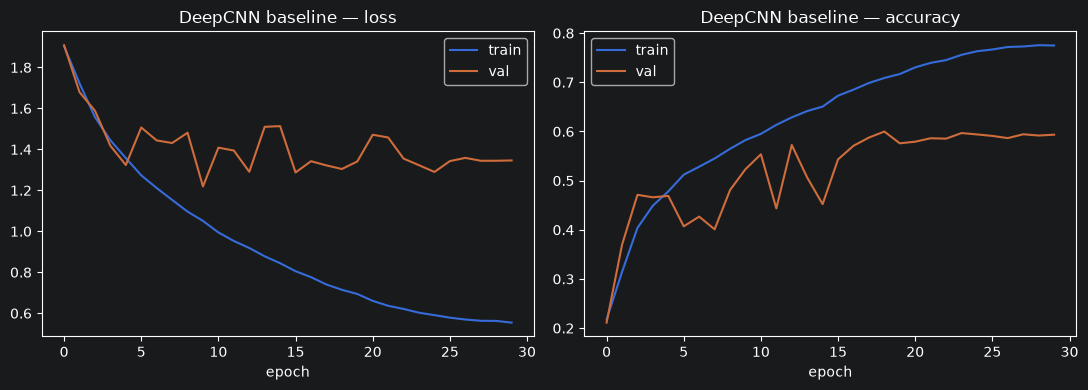


SmallCNN (tuned) test ~0.489  |  DeepCNN baseline test: 0.608  f1 0.605


In [14]:
deep_model, deep_hist = fit(lambda: DeepCNN(), arch="DeepCNN", epochs=30, lr=3e-4,
                            lr_schedule="cosine", augment=False,
                            notes="Arch 3 baseline: 3 conv blocks + BN + GAP head, dropout 0.5.")
plot_history(deep_hist, title="DeepCNN baseline")
print(f"\nSmallCNN (tuned) test ~0.489  |  DeepCNN baseline test: {deep_hist['test_acc']:.3f}  "
      f"f1 {deep_hist['test_f1']:.3f}")


## 9. Tuning DeepCNN

### Search 1 — Learning rate (log-spaced grid)

In [15]:
lr_df = grid_search(DeepCNN, arch="DeepCNN",
                    param_grid={"lr": [1e-4, 3e-4, 1e-3, 3e-3]},
                    fixed=dict(epochs=30, lr_schedule="cosine", augment=False),
                    study="tune-lr")
display(lr_df)

BEST_LR = float(lr_df.iloc[0]["lr"])
print(f"\n>>> best LR = {BEST_LR:g}  "
      f"(val {lr_df.iloc[0]['best_val_acc']:.4f}, test {lr_df.iloc[0]['test_acc']:.4f})")


[grid] 4 combinations
--- grid 1/4: {'lr': 0.0001} ---


[DeepCNN] best val acc 0.569 @ epoch 23  |  TEST acc 0.564  f1 0.542


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▂▃▁▃▄▄▄▆▄▄▃█▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄
gap/loss,▁▃▁▂▂▃▃▄▄▆▅█▅▅▆▅▅▇▆▆▆▇▇▆▆▆▇▇▇▇
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▂▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇██████████
train/loss,█▇▇▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/acc,▁▁▄▄▄▄▄▃▅▅▇▂▇▆▆▇▇▇▇███████████
val/f1_macro,▁▁▄▄▄▄▄▄▅▄▆▃▆▆▆▆▇█▇█▇██▇██████
val/loss,██▅▆▄▄▄▄▄▄▄▆▂▂▃▁▁▃▂▂▂▂▂▁▁▂▂▂▂▂
best_epoch,23
best_val_acc,0.56924


--- grid 2/4: {'lr': 0.0003} ---


[DeepCNN] best val acc 0.600 @ epoch 19  |  TEST acc 0.608  f1 0.605


...

--- grid 4/4: {'lr': 0.003} ---


[DeepCNN] best val acc 0.607 @ epoch 14  |  TEST acc 0.619  f1 0.597


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▃▂▁▂▂▃▄▄▃▃▃▅▄▄▅▅▅▆▆▆▇▇▇▇▇█████
gap/loss,▁▁▁▁▁▂▃▃▂▂▃▅▃▄▄▄▅▅▆▆▆▇▇███████
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▂▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████████
train/loss,█▇▇▆▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
val/acc,▁▃▆▆▆▆▆▆▇▇█▇██████████████████
val/f1_macro,▁▃▅▅▆▆▅▅▆▇█▇▇█▇███████████████
val/loss,█▆▄▃▂▂▄▃▁▁▂▅▂▂▂▂▄▃▄▅▆▅▆█▇█████
best_epoch,14
best_val_acc,0.60658


,epochs,lr_schedule,augment,lr,best_val_acc,test_acc,test_f1
0,30,cosine,False,0.0010,0.6163,0.6152,0.6067
1,30,cosine,False,0.0030,0.6066,0.6186,0.5967
2,30,cosine,False,0.0003,0.5999,0.6082,0.6052
3,30,cosine,False,0.0001,0.5692,0.5642,0.5421



>>> best LR = 0.001  (val 0.6163, test 0.6152)


### Search 2 — Dropout 

In [17]:
drop_df = grid_search(DeepCNN, arch="DeepCNN",
                      param_grid={"dropout": [0.3, 0.5, 0.6, 0.7]},
                      fixed=dict(epochs=30, lr=BEST_LR, lr_schedule="cosine", augment=False),
                      study="tune-dropout")
display(drop_df)

BEST_DROPOUT = float(drop_df.iloc[0]["dropout"])
print(f"\n>>> best dropout = {BEST_DROPOUT:g}  "
      f"(val {drop_df.iloc[0]['best_val_acc']:.4f}, test {drop_df.iloc[0]['test_acc']:.4f}, "
      f"f1 {drop_df.iloc[0]['test_f1']:.4f})")


[grid] 4 combinations
--- grid 1/4: {'dropout': 0.3} ---


epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
gap/acc,▂▁▁▂▃▅▃▄▄▃▄▆▄▅█▆▆▇▆▇██
gap/loss,▁▁▂▃▂▃▃▃▃▃▄▅▅▅▆▅▆█▆▇██
lr,█████▇▇▇▇▆▆▅▅▅▄▄▃▃▂▂▁▁
train/acc,▁▃▃▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
train/loss,█▇▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁
val/acc,▁▅▆▆▆▅▆▆▇▇▇▆█▇▅▇█▇████
val/f1_macro,▁▄▄▅▅▄▆▆▆▇▇▆█▇▆▇█▇████
val/loss,▆▄▄▄▁▄▂▂▁▁▂▅▄▃▇▃▃█▄▆▇▆
epoch,22
gap/acc,0.25706


[DeepCNN] best val acc 0.616 @ epoch 19  |  TEST acc 0.616  f1 0.603


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▂▁▁▂▂▄▃▄▃▃▃▅▄▄▇▆▅▆▆▇▇▇▇███████
gap/loss,▁▁▂▂▂▃▃▃▃▃▄▅▅▅▆▅▅▇▆▇█▇█▇██████
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████████
train/loss,█▇▆▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/acc,▁▅▆▆▆▅▆▆▇▇▇▆█▇▅▇█▇████████████
val/f1_macro,▁▄▄▅▅▄▆▅▆▇▇▆█▇▆▇█▇████████████
val/loss,▆▄▄▄▁▄▂▂▁▁▂▅▄▃▇▃▃█▄▆▇▆█▆▇▇▇▇▇▇
best_epoch,19
best_val_acc,0.61605


--- grid 2/4: {'dropout': 0.5} ---


...

--- grid 4/4: {'dropout': 0.7} ---


[DeepCNN] best val acc 0.598 @ epoch 29  |  TEST acc 0.607  f1 0.605


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▁▁▁▂▂▃▃▇▃▃▃▄▄▄▆▅▅▅▆▆▆▇▇▇▇▇████
gap/loss,▁▁▁▁▁▂▂▄▃▂▃▃▄▄▄▄▅▆▆▆▆▇▇▇▇█████
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▁▂▃▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████████
train/loss,█▇▇▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/acc,▁▂▃▄▅▅▆▃▆▇▇▇▇█▆▇▇█████████████
val/f1_macro,▁▂▃▄▅▅▅▄▅▇▇▇▇▇▇▇▇▇████████████
val/loss,█▇▆▄▂▃▂▄▂▁▂▁▂▂▂▁▁▃▂▂▂▃▄▃▃▄▄▄▄▄
best_epoch,29
best_val_acc,0.59794


,epochs,lr,lr_schedule,augment,dropout,best_val_acc,test_acc,test_f1
0,30,0.001,cosine,False,0.5,0.6163,0.6152,0.6067
1,30,0.001,cosine,False,0.3,0.6160,0.6158,0.6025
2,30,0.001,cosine,False,0.6,0.6004,0.6272,0.6118
3,30,0.001,cosine,False,0.7,0.5979,0.6074,0.6047



>>> best dropout = 0.5  (val 0.6163, test 0.6152, f1 0.6067)


### Search 3 — Data augmentation 

In [21]:
aug_df = grid_search(DeepCNN, arch="DeepCNN",
                     param_grid={"augment": [False, True]},
                     fixed=dict(epochs=45, lr=BEST_LR, dropout=BEST_DROPOUT,
                                lr_schedule="cosine"),
                     study="tune-augment")
display(aug_df)

BEST_AUGMENT = bool(aug_df.iloc[0]["augment"])
print(f"\n>>> best augment = {BEST_AUGMENT}  "
      f"(val {aug_df.iloc[0]['best_val_acc']:.4f}, test {aug_df.iloc[0]['test_acc']:.4f}, "
      f"f1 {aug_df.iloc[0]['test_f1']:.4f})")
print("   vs no-aug @30 ep baseline: val 0.6163  (more-epochs effect = this row's no-aug minus 0.6163)")


[grid] 2 combinations
--- grid 1/2: {'augment': False} ---


epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
gap/acc,▂▂▁▂▃▅▃█▃▃▃▄▄▄
gap/loss,▂▁▁▂▂▃▂▇▃▃▄▅█▅
lr,████▇▇▆▆▅▅▄▃▂▁
train/acc,▁▂▄▅▅▆▆▆▇▇▇███
train/loss,█▇▆▅▄▄▃▃▂▂▂▂▁▁
val/acc,▁▃▆▇▆▄▇▂▇█████
val/f1_macro,▁▃▆▆▆▅▆▄▇▇██▇█
val/loss,▇▅▃▄▂▄▂█▂▁▂▄█▃
epoch,14
gap/acc,0.11117


[DeepCNN] epoch 01/45  train_loss 1.900 acc 0.208 | val_loss 1.891 acc 0.217 f1 0.155
[DeepCNN] epoch 02/45  train_loss 1.726 acc 0.292 | val_loss 1.655 acc 0.319 f1 0.270
[DeepCNN] epoch 03/45  train_loss 1.548 acc 0.408 | val_loss 1.429 acc 0.484 f1 0.411
[DeepCNN] epoch 04/45  train_loss 1.411 acc 0.463 | val_loss 1.519 acc 0.502 f1 0.427
[DeepCNN] epoch 05/45  train_loss 1.313 acc 0.498 | val_loss 1.319 acc 0.473 f1 0.422
[DeepCNN] epoch 06/45  train_loss 1.225 acc 0.524 | val_loss 1.477 acc 0.391 f1 0.366
[DeepCNN] epoch 07/45  train_loss 1.151 acc 0.552 | val_loss 1.287 acc 0.510 f1 0.451
[DeepCNN] epoch 08/45  train_loss 1.087 acc 0.573 | val_loss 1.979 acc 0.267 f1 0.296
[DeepCNN] epoch 09/45  train_loss 1.020 acc 0.591 | val_loss 1.299 acc 0.548 f1 0.471
[DeepCNN] epoch 10/45  train_loss 0.979 acc 0.607 | val_loss 1.182 acc 0.555 f1 0.518
[DeepCNN] epoch 11/45  train_loss 0.923 acc 0.627 | val_loss 1.245 acc 0.572 f1 0.534
[DeepCNN] epoch 12/45  train_loss 0.886 acc 0.641 | va

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
gap/acc,▂▂▁▂▃▄▃▇▃▃▄▃▄▅▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇███████████
gap/loss,▁▁▁▂▁▂▂▄▂▂▃▅▃▃▃▄▄▅▆▅▆▆▆▆▆▇▇▇▇▇▇█████████
lr,████████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train/acc,▁▂▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇█████████████
train/loss,█▇▇▆▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▆▆▆▄▆▂▇▇▇▇▇▇████▇▇▇█▇███▇█████████████
val/f1_macro,▁▃▅▅▅▄▆▃▇▇▇▆▇▆▇██▇▇█▇█▇█████████████████
val/loss,▅▄▃▃▂▃▂▆▁▁▃▆▃▂▁▃▄▄▆▄▆▅▅▅▅▆▆▇▇▇▇█▇███████
best_epoch,37
best_val_acc,0.61103


--- grid 2/2: {'augment': True} ---


[DeepCNN] epoch 01/45  train_loss 1.924 acc 0.193 | val_loss 1.879 acc 0.220 f1 0.170
[DeepCNN] epoch 02/45  train_loss 1.808 acc 0.255 | val_loss 1.830 acc 0.242 f1 0.209
[DeepCNN] epoch 03/45  train_loss 1.667 acc 0.354 | val_loss 1.521 acc 0.402 f1 0.355
[DeepCNN] epoch 04/45  train_loss 1.549 acc 0.410 | val_loss 1.452 acc 0.465 f1 0.402
[DeepCNN] epoch 05/45  train_loss 1.459 acc 0.445 | val_loss 1.357 acc 0.499 f1 0.420
[DeepCNN] epoch 06/45  train_loss 1.383 acc 0.474 | val_loss 1.360 acc 0.483 f1 0.406
[DeepCNN] epoch 07/45  train_loss 1.345 acc 0.487 | val_loss 1.293 acc 0.530 f1 0.452
[DeepCNN] epoch 08/45  train_loss 1.305 acc 0.505 | val_loss 1.332 acc 0.521 f1 0.475
[DeepCNN] epoch 09/45  train_loss 1.265 acc 0.520 | val_loss 1.203 acc 0.555 f1 0.503
[DeepCNN] epoch 10/45  train_loss 1.240 acc 0.533 | val_loss 1.173 acc 0.564 f1 0.498
[DeepCNN] epoch 11/45  train_loss 1.232 acc 0.533 | val_loss 1.212 acc 0.551 f1 0.494
[DeepCNN] epoch 12/45  train_loss 1.193 acc 0.543 | va

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
gap/acc,▄▇▂▁▁▅▂▅▃▄▃▄▄▄▆▅▅▆▆▇▆▆▇▇▆▇▇▇▆▇▇█▇█▇█▇▇▇█
gap/loss,▃▄▁▂▂▃▃▄▂▃▃▅▄▆▇▅▄▅▆▅▅▆▆█▆▆▆▇▇▇▇▇▇▇█▇▇██▇
lr,████████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train/acc,▁▂▃▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
train/loss,█▇▆▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▁▄▅▆▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇██▇█████████████████
val/f1_macro,▁▂▄▅▅▅▆▆▆▆▇▇▇▇▆▇▇▇▇▇▇▇▇█████████████████
val/loss,██▅▄▄▄▃▃▂▂▂▃▂▂▃▂▁▁▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,39
best_val_acc,0.63054


,epochs,lr,dropout,lr_schedule,augment,best_val_acc,test_acc,test_f1
0,45,0.001,0.5,cosine,True,0.6305,0.6484,0.6267
1,45,0.001,0.5,cosine,False,0.6110,0.6071,0.5955



>>> best augment = True  (val 0.6305, test 0.6484, f1 0.6267)
   vs no-aug @30 ep baseline: val 0.6163  (more-epochs effect = this row's no-aug minus 0.6163)


[DeepCNN] epoch 01/75  train_loss 1.924 acc 0.193 | val_loss 1.879 acc 0.220 f1 0.170
[DeepCNN] epoch 02/75  train_loss 1.808 acc 0.255 | val_loss 1.876 acc 0.225 f1 0.172
[DeepCNN] epoch 03/75  train_loss 1.671 acc 0.352 | val_loss 1.603 acc 0.317 f1 0.303
[DeepCNN] epoch 04/75  train_loss 1.548 acc 0.410 | val_loss 1.412 acc 0.482 f1 0.409
[DeepCNN] epoch 05/75  train_loss 1.459 acc 0.448 | val_loss 1.369 acc 0.496 f1 0.419
[DeepCNN] epoch 06/75  train_loss 1.383 acc 0.477 | val_loss 1.375 acc 0.492 f1 0.414
[DeepCNN] epoch 07/75  train_loss 1.346 acc 0.489 | val_loss 1.294 acc 0.522 f1 0.449
[DeepCNN] epoch 08/75  train_loss 1.305 acc 0.506 | val_loss 1.333 acc 0.537 f1 0.495
[DeepCNN] epoch 09/75  train_loss 1.272 acc 0.516 | val_loss 1.238 acc 0.542 f1 0.476
[DeepCNN] epoch 10/75  train_loss 1.246 acc 0.530 | val_loss 1.177 acc 0.563 f1 0.504
[DeepCNN] epoch 11/75  train_loss 1.238 acc 0.532 | val_loss 1.239 acc 0.548 f1 0.489
[DeepCNN] epoch 12/75  train_loss 1.200 acc 0.544 | va

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
gap/acc,██▁▃▅▅▅▄▅▅▆▆▅▆▆▆▅▆▇▇▆▆▇█▇▇█▇▇███████████
gap/loss,▂▁▂▃▂▃▂▅▃▄▄▄▄▄▆▅▄▄▅▅▆▆▅▆▆▆▇▇▇▇▇██▇▇█████
lr,████████▇▇▇▇▇▇▇▇▆▆▆▆▅▅▄▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train/acc,▁▃▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,█▇▆▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▁▃▅▆▆▆▆▇▆▇▇▇▇▇▇▇███████████████████████
val/f1_macro,▁▁▃▅▅▅▆▆▆▇▇▇▆▇▇▇▇▇▇▇██▇█████████████████
val/loss,██▄▄▃▃▂▃▃▂▁▂▂▂▂▂▁▁▁▂▁▂▁▂▁▁▁▁▂▂▂▁▂▂▂▂▂▂▂▂
best_epoch,69
best_val_acc,0.64865


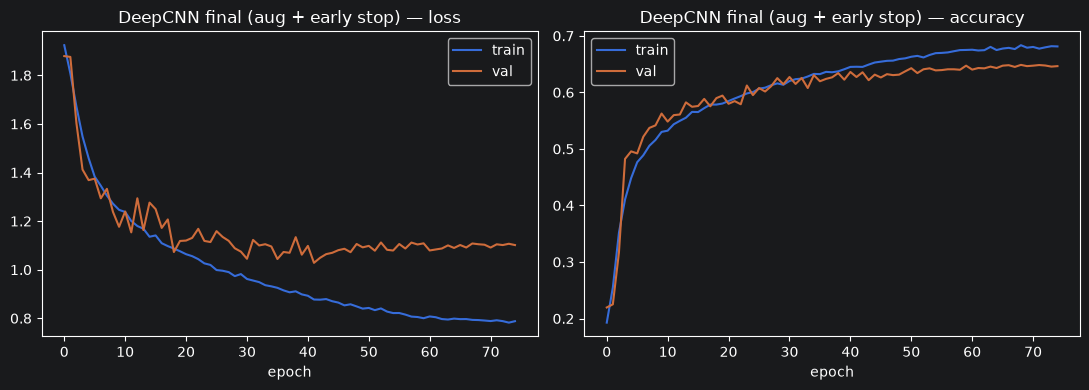


DeepCNN FINAL: best val 0.6486 @ ep 69  (stopped at ep 75)  |  TEST acc 0.6665  f1 0.6587


In [27]:
deep_final, deep_final_hist = fit(
    lambda: DeepCNN(dropout=BEST_DROPOUT), arch="DeepCNN",
    epochs=75, lr=BEST_LR, augment=BEST_AUGMENT, lr_schedule="cosine",
    early_stop_patience=15, early_stop_min_delta=0.001,
    study="final", run_name="DeepCNN-final-aug-earlystop", watch=True,
    notes="Final DeepCNN: lr 1e-3, dropout 0.5, augmentation, cosine, early-stop patience 15 / min_delta 0.001.")

plot_history(deep_final_hist, title="DeepCNN final (aug + early stop)")
print(f"\nDeepCNN FINAL: best val {deep_final_hist['best_val_acc']:.4f} "
      f"@ ep {deep_final_hist['best_epoch']}  (stopped at ep {deep_final_hist['stopped_epoch']})  "
      f"|  TEST acc {deep_final_hist['test_acc']:.4f}  f1 {deep_final_hist['test_f1']:.4f}")